In [1]:
import numpy as np

In [2]:
folder_path = r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\saved_data\ROAD"

int_id_data = np.load(folder_path + r"\int_id_data.npy", allow_pickle=True)
attack_labels = np.load(folder_path + r"\attack_labels.npy", allow_pickle=True)


int_id_data_test = np.load(folder_path + r"\int_id_data_test.npy", allow_pickle=True)
attack_labels_test = np.load(folder_path + r"\attack_labels_test.npy", allow_pickle=True)

In [3]:
import builtins
import numpy as np


def sliding_windows_id_data(samples, labels, window_size=8, step=2, attack_labels=('T', 'D', 'F', 'S')):
    n = len(samples)

    if isinstance(attack_labels, str):
        attack_labels = (attack_labels,)

    windows = []
    window_labels = []
    next_id_datas = []
    

    for start in range(0, n - window_size, step):
        end = start + window_size
        window_slice = labels[start:end]

        windows.append(samples[start:end])
        next_id_datas.append(samples[end])

        matching_attack = builtins.next(
            (label for label in attack_labels if label in window_slice),
            'R'
        )
        window_labels.append(matching_attack)

    return (
        np.array(windows, dtype=np.uint8),
        np.array(next_id_datas, dtype=object),
        np.array(window_labels, dtype=object)
    )

In [4]:
windows, windowed_labels = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data[i], attack_labels[i])
    windows.extend(windows_batch)
    windowed_labels.extend(windowed_labels_batch)


In [5]:
windowed_labels = np.array(windowed_labels)
attack_onehot = np.zeros((len(windowed_labels), 2), dtype=np.uint8)
attack_onehot[windowed_labels == 'R', 0] = 1
attack_onehot[windowed_labels == 'T', 1] = 1

print(attack_onehot[:10])

[[1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


In [6]:
windows_test, windowed_labels_test = [], []
for i in range(len(int_id_data)):
    windows_batch, next_values, windowed_labels_batch = sliding_windows_id_data(int_id_data_test[i], attack_labels_test[i])
    windows_test.extend(windows_batch)
    windowed_labels_test.extend(windowed_labels_batch)

In [7]:
windowed_labels_test = np.array(windowed_labels_test)

attack_onehot_test = np.zeros((len(windowed_labels_test), 2), dtype=np.uint8)
attack_onehot_test[windowed_labels_test == 'R', 0] = 1
attack_onehot_test[windowed_labels_test == 'T', 1] = 1

print(attack_onehot_test[:10])

[[0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]]


In [8]:
windows = np.array(windows)
windows_test = np.array(windows_test)

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(8,10)), 
    Dense(64, activation="sigmoid"), 
    Dense(32, activation='sigmoid'), 
    Dense(2, activation='softmax'),  
])

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mod = model.fit(windows, attack_onehot, epochs=10, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/10
4107/4107 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9760 - loss: 0.1032 - val_accuracy: 0.9997 - val_loss: 0.0233
Epoch 2/10
4107/4107 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9774 - loss: 0.0831 - val_accuracy: 0.9987 - val_loss: 0.0197
Epoch 3/10
4107/4107 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9791 - loss: 0.0746 - val_accuracy: 0.9983 - val_loss: 0.0215
Epoch 4/10
4107/4107 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9802 - loss: 0.0700 - val_accuracy: 0.9971 - val_loss: 0.0229
Epoch 5/10
4107/4107 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9811 - loss: 0.0661 - val_accuracy: 0.9976 - val_loss: 0.0182
Epoch 6/10
4107/4107 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9825 - loss: 0.0615 - val_accuracy: 0.9966 - val_loss: 0.0191
Epoch 7/10
4107/4107 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9836 - loss: 0.0575 - val_accuracy: 0.9971 - val_loss: 0.0186
Epoch 8/10
4107/4107 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9845 - loss: 0

In [11]:
loss, accuracy = model.evaluate(windows_test, attack_onehot_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.0465
Test accuracy: 0.9871


In [12]:
label_map = np.array(['R', 'T'])

def onehot_to_labels(onehot):
    return label_map[np.argmax(onehot, axis=1)]

recovered_labels = onehot_to_labels(model.predict(windows_test))
print(recovered_labels[:20])

80212/80212 ━━━━━━━━━━━━━━━━━━━━ 59s 731us/step
['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R']


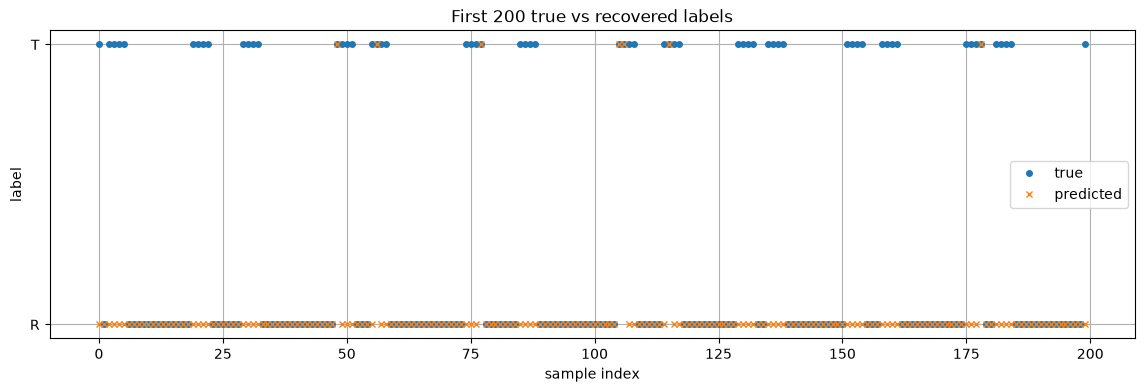

In [13]:
true_labels = onehot_to_labels(attack_onehot_test)
pred_labels = recovered_labels

n = min(200, len(true_labels))
label_to_num = {label: i for i, label in enumerate(label_map)}

true_nums = [label_to_num[label] for label in true_labels[:n]]
pred_nums = [label_to_num[label] for label in pred_labels[:n]]

plt.figure(figsize=(14, 4))
plt.plot(true_nums, label='true', marker='o', linestyle='None', markersize=4)
plt.plot(pred_nums, label='predicted', marker='x', linestyle='None', markersize=4)
plt.yticks(range(len(label_map)), label_map)
plt.xlabel('sample index')
plt.ylabel('label')
plt.title(f'First {n} true vs recovered labels')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

y_pred_probs = model.predict(windows_test)
y_pred = onehot_to_labels(y_pred_probs)
y_true = onehot_to_labels(attack_onehot_test)

report = classification_report(
    y_true,
    y_pred,
    labels=label_map,
    target_names=label_map,
    zero_division=0,
)

cm = confusion_matrix(y_true, y_pred, labels=label_map)

tps = np.diag(cm)
fps = cm.sum(axis=0) - tps
fns = cm.sum(axis=1) - tps
tns = cm.sum() - (tps + fps + fns)

fpr = np.divide(fps, fps + tns, out=np.zeros_like(fps, dtype=float), where=(fps + tns) != 0)
fnr = np.divide(fns, fns + tps, out=np.zeros_like(fns, dtype=float), where=(fns + tps) != 0)

print("Classification report:")
print(report)
print("Confusion matrix:")
print(cm)

precision = precision_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)

for label, p, r, f, fp_rate, fn_rate in zip(label_map, precision, recall, f1, fpr, fnr):
    print(
        f"{label}: precision={p:.4f}, recall={r:.4f}, "
        f"f1={f:.4f}, false positive rate={fp_rate:.4f}, false negative rate={fn_rate:.4f}"
    )

80212/80212 ━━━━━━━━━━━━━━━━━━━━ 60s 752us/step
Classification report:
              precision    recall  f1-score   support

           R       0.99      1.00      0.99   2517648
           T       0.85      0.40      0.54     49109

    accuracy                           0.99   2566757
   macro avg       0.92      0.70      0.77   2566757
weighted avg       0.99      0.99      0.98   2566757

Confusion matrix:
[[2514159    3489]
 [  29674   19435]]
R: precision=0.9883, recall=0.9986, f1=0.9934, false positive rate=0.6042, false negative rate=0.0014
T: precision=0.8478, recall=0.3958, f1=0.5396, false positive rate=0.0014, false negative rate=0.6042


In [15]:
hello()

import os
from tensorflow import keras

os.makedirs("saved_models", exist_ok=True)
model.save(os.path.join("saved_models", "HCRL_model_2.h5"))
print("Saved model to saved_models/HCRL_model_2.h5")

NameError: name 'hello' is not defined

In [ ]:
import tensorflow_model_optimization as tfmot

prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

pruning_params = {
    "pruning_schedule":
        tfmot.sparsity.keras.PolynomialDecay(
            initial_sparsity=0.0,
            final_sparsity=0.5,
            begin_step=0,
            end_step=2000
        )
}

pruned_model = prune_low_magnitude(
    model,
    pruning_params
)

pruned_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tfmot.sparsity.keras.UpdatePruningStep()
]

history = pruned_model.fit(
    windows_test, attack_onehot,
    epochs=5,
    callbacks=callbacks
)

ValueError: `prune_low_magnitude` can only prune an object of the following types: keras.models.Sequential, keras functional model, keras.layers.Layer, list of keras.layers.Layer. You passed an object of type: Sequential.

In [ ]:
loss_p, accuracy_p = pruned_model.evaluate(windows_test, attack_onehot_test, verbose=0)
print(f"Test loss: {loss_p:.4f}")
print(f"Test accuracy: {accuracy_p:.4f}")

y_pred_probs_p = pruned_model.predict(windows_test)
y_pred_p = onehot_to_labels(y_pred_probs_p)
y_true_p = onehot_to_labels(attack_onehot_test)

report_p = classification_report(
    y_true_p,
    y_pred_p,
    labels=label_map,
    target_names=label_map,
    zero_division=0,
)
cm_p = confusion_matrix(y_true_p, y_pred_p, labels=label_map)

tps_p = np.diag(cm_p)
fps_p = cm_p.sum(axis=0) - tps_p
fns_p = cm_p.sum(axis=1) - tps_p
tns_p = cm_p.sum() - (tps_p + fps_p + fns_p)

fpr_p = np.divide(fps_p, fps_p + tns_p, out=np.zeros_like(fps_p, dtype=float), where=(fps_p + tns_p) != 0)
fnr_p = np.divide(fns_p, fns_p + tps_p, out=np.zeros_like(fns_p, dtype=float), where=(fns_p + tps_p) != 0)

print("Classification report:")
print(report_p)
print("Confusion matrix:")
print(cm_p)

precision_p = precision_score(y_true_p, y_pred_p, labels=label_map, average=None, zero_division=0)
recall_p = recall_score(y_true_p, y_pred_p, labels=label_map, average=None, zero_division=0)
f1_p = f1_score(y_true_p, y_pred_p, labels=label_map, average=None, zero_division=0)

for label, p, r, f, fp_rate, fn_rate in zip(label_map, precision_p, recall_p, f1_p, fpr_p, fnr_p):
    print(
        f"{label}: precision={p:.4f}, recall={r:.4f}, "
        f"f1={f:.4f}, false positive rate={fp_rate:.4f}, false negative rate={fn_rate:.4f}"
    )